In [53]:
import os
import re
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# User data directory path
user_data_dir = "../../../USER_DATA/"

# Match format like: USER_1_TASK_1_QWERTY.csv
pattern = re.compile(r'USER_(\d+)_TASK_([12])_(QWERTY|SWIPE)\.csv', re.IGNORECASE)

In [54]:
# Map used to group each user's QWERTY/SWIPE trials
user_method_data = {}

# {
#   (USER_X, QWERTY) : { Task 1: Metric Averages, Task 2: Metric Averages }
#   (USER_X, SWIPE)  : { Task 1: Metric Averages, Task 2: Metric Averages }
# }

# Parse all CSVs 
for filename in os.listdir(user_data_dir):
    match = pattern.match(filename)
    if match:
        user_id, task_num, method = match.groups()
        user_key = (f"USER_{user_id}", method.upper())
        task_key = f"TASK_{task_num}"

        file_path = os.path.join(user_data_dir, filename)

        df = pd.read_csv(file_path)
        numeric_avg = df.select_dtypes(include="number").mean()

        # Add the user metric values to the map
        if user_key not in user_method_data:
            user_method_data[user_key] = {}
        user_method_data[user_key][task_key] = numeric_avg

In [ ]:

# Build summary rows
summary_rows = []
for (user, method), task_metrics in user_method_data.items():
    if "TASK_1" in task_metrics and "TASK_2" in task_metrics:
        avg = (task_metrics["TASK_1"] + task_metrics["TASK_2"]) / 2
        row = avg.to_dict()
        row["User"] = user
        row["Method"] = method
        summary_rows.append(row)


## Create DataFrame and reorder columns
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[["User", "Method"] + [col for col in summary_df.columns if col not in ["User", "Method"]]]
summary_df = summary_df.drop(columns = ["Trial #", "Start Time", " End Time", "End Time"])

# Verify summary_df is the data we need
print(summary_df);

      User  Method  Time Taken (s)  Total Keystrokes  \
0   USER_1  QWERTY        7.381073         28.966667   
1   USER_1   SWIPE       18.089117         27.800000   
2   USER_2  QWERTY        7.272823         36.500000   
3   USER_2   SWIPE       14.889093         29.200000   
4   USER_3  QWERTY        6.304057         35.333333   
5   USER_3   SWIPE       17.894160         30.833333   
6   USER_4  QWERTY        6.851030         38.666667   
7   USER_4   SWIPE       14.772613         29.366667   
8   USER_5  QWERTY        8.382213         34.466667   
9   USER_5   SWIPE       18.175017         29.900000   
10  USER_6  QWERTY        6.722967         35.466667   
11  USER_6   SWIPE       18.561610         29.166667   

    Character Error Rate [Edit Distance] (%)  Accuracy [Edit Distance] (%)  \
0                                   4.591138                     95.408862   
1                                   1.086636                     98.913364   
2                                   5

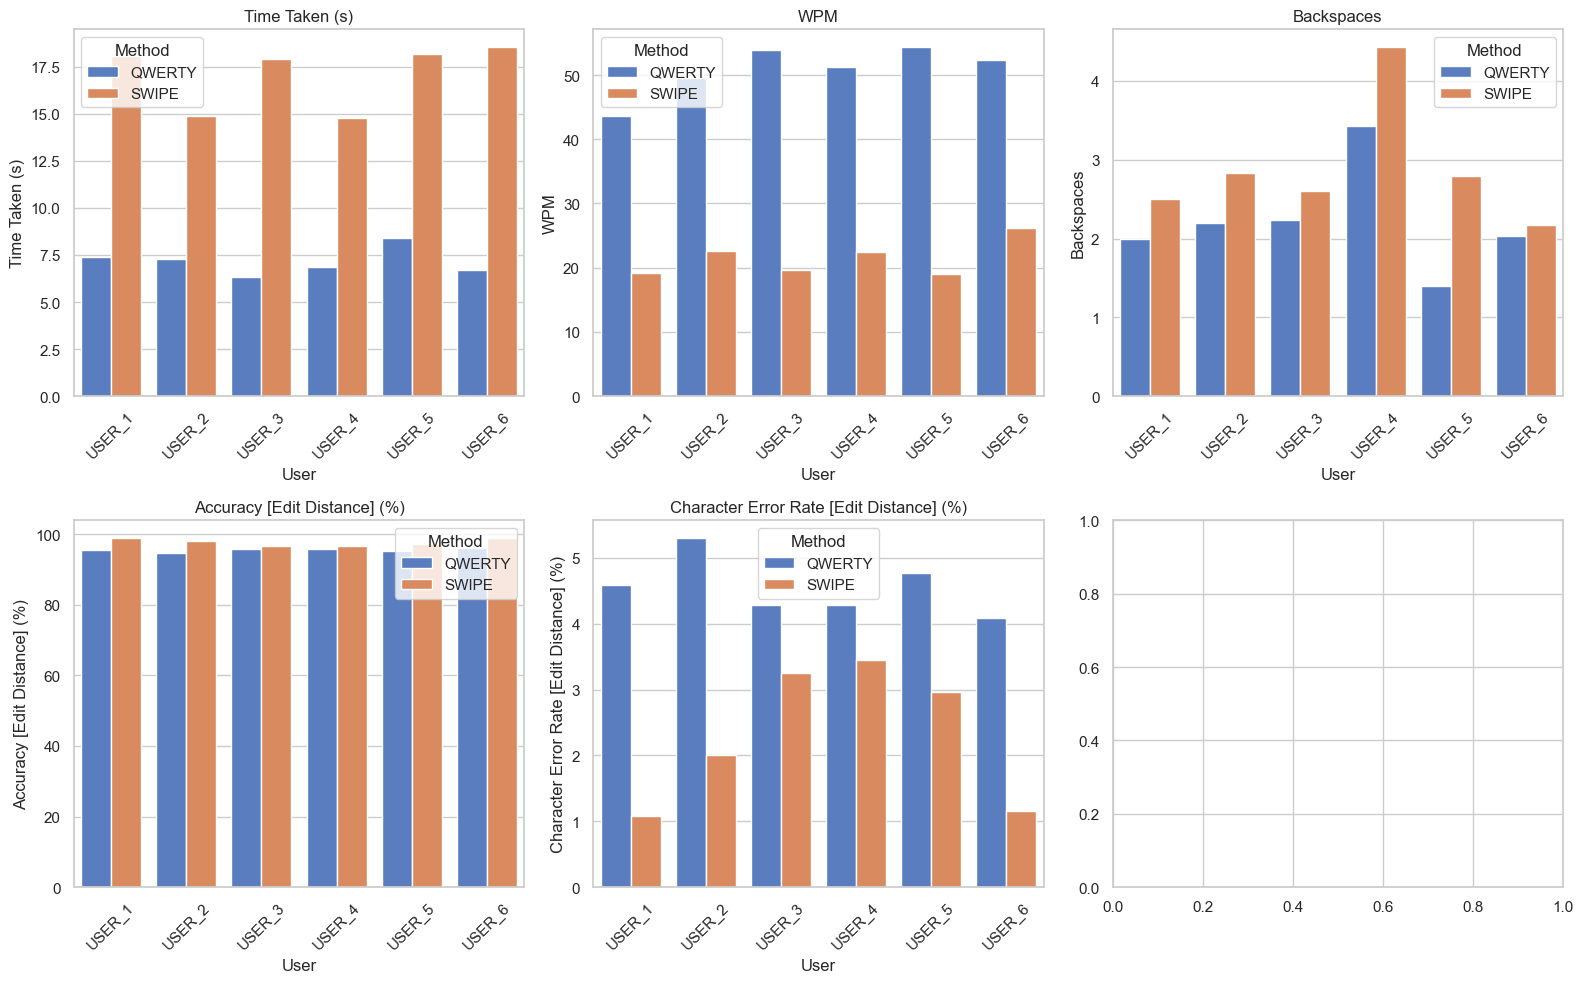

In [64]:
# Now we create visualizations using bar graph so each bar group is per 
# User with the 2 methods and the following metrics as the y-axis: Time Taken, WPM, backspaces, and Accuracy
sns.set(style="whitegrid")

# Metrics we will plot
metrics = ["Time Taken (s)", "WPM", "Backspaces", "Accuracy [Edit Distance] (%)", "Character Error Rate [Edit Distance] (%)"]

fig, axes = plt.subplots(2, math.ceil(len(metrics) / 2), figsize=(16, 10))
axes = axes.flatten()

# Create one subplot per metric
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sns.barplot(
        data=summary_df,
        x="User",
        y=metric,
        hue="Method",
        ax=ax,
        palette="muted"
    )
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel("User")
    ax.legend(title="Method")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()